# Plot polar maps of boreal domain data - AGB and HT raster data frame maps

Paul Montesano  
Fall 2022  
run this notebook in a conda R env

In [3]:
system("conda activate r-with-gdal")

In [1]:
install.packages("mapproj")

Warning message in install.packages("mapproj"):
“installation of package ‘mapproj’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [12]:
#library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)


library(rgeos) # needed for fortify_sf
library(mapproj)
#library(rgee)
#library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)
#library(feather)

library(ddplyr)

#conda install -c conda-forge r-rnaturalearth r-rnaturalearthdata r-mapproj r-rgeos r-viridis r-wesanderson r-patchwork r-aws.s3 r-feather r-rockchalk

ERROR: Error in library(ddplyr): there is no package called ‘ddplyr’


# Paths of final tindex master files

## Set output figure dir.

In [5]:
OUT_FIGURE_DIR = '/projects/my-public-bucket/boreal_AGB/paper_figs'
dir.create(OUT_FIGURE_DIR)

Warning message in dir.create(OUT_FIGURE_DIR):
“'/projects/my-public-bucket/boreal_AGB/paper_figs' already exists”


### Mapping functions and vars

In [18]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


In [19]:
crs_canalb = "+proj=aea +lat_0=40 +lon_0=180 +lat_1=50 +lat_2=70 +x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs"
crs_albers = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
crs_gcs = "+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs"

# Map Boreal EXTENT, ATL08, and Biomass

#### Read boreal extent, read tiles, then clip tiles to boreal extent

In [20]:
wwf_circ_dis_fn

/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp

In [21]:
boreal_shp_fn = '/projects/my-public-bucket/misc_files/Ecoregions2017_boreal_m.shp'
boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg'
#boreal_shp_fn = '/projects/shared-buckets/montesano/databank/arc/boreal.shp'
#boreal_shp_fn = wwf_circ_dis_fn
boreal = st_read(boreal_shp_fn) %>% st_transform(crs=crs_canalb)

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/shared-buckets/montesano/databank/arc/wwf_circumboreal_Dissolve.gpkg' 
  using driver `GPKG'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


### Get all tiles delivered to DAAC for this project: boreal extent + down to ~50N

In [22]:
if(ADAPT){
    boreal_tile_DAAC_path = '/home/pmontesa/pmontesa/userfs02/projects/above_icesat2/boreal_tiles/boreal_tiles_v004_DAAC.gpkg'
    }else{
    boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
    }
boreal_tiles_DAAC = st_read(boreal_tile_DAAC_path)
boreal_tile_num_DAAC_list =  boreal_tiles_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
boreal_tile_num_DAAC_list = unlist(boreal_tile_num_DAAC_list[[1]])
length(boreal_tile_num_DAAC_list)

Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3902 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


[1] 3902

In [24]:
#boreal_tiles_gcs_DAAC = fortify_sf(boreal_tiles_gcs_DAAC) 

### Map AGB mean and AGB std
##### Using a raster that gets reprojected

In [25]:
#r = raster('/projects/shared-buckets/alexdevseed/icesat2_boreal_biomass_900m.tif', band=1)
# r_fn = '/projects/shared-buckets/nathanmthomas/DPS_tile_lists/07/AGB_tindex_average_3000m.tif'
# r_fn = '/projects/shared-buckets/nathanmthomas/DPS_tile_lists/AGB/fall2022/map_boreal_2022_v3/11/AGB_tindex_average_3000m.tif'
# r_fn = '/projects/shared-buckets/nathanmthomas/DPS_tile_lists/AGB/winter2023/map_boreal_2022_rh_noground_v4/AGB_tindex_average_4500m.tif'
r_fn = '/projects/my-public-bucket/DPS_tile_lists/BOREAL_MAP/boreal_agb_2024_v6/AGB_H30_2020/Version2_SD/AGB_tindex_average_4500m.tif'
r_agb = as.data.frame(terra::rast(r_fn), xy=TRUE)
names(r_agb) = c('x','y','mean_agb', 'std_agb')

# r_agb_mean = terra::rast(r_fn, band=1)
# r_agb_std = terra::rast(r_fn, band=2)
# names(r_agb_mean) = 'mean_agb'
# names(r_agb_std) = 'std_agb'

#plot(r_agb_mean)
#plot(r_agb_std)

In [26]:
dim(r_agb)

[1] 1701022       4

In [27]:
r_p <- reshape2::melt(dplyr::sample_frac(r_agb, 0.1) , id.vars=c('x','y'))


In [28]:
head(r_p)

,x,y,variable,value
,<dbl>,<dbl>,<fct>,<dbl>
1,-1069228,2320054,mean_agb,7.109013
2,-1807228,8197054,mean_agb,35.503967
3,5253272,4430554,mean_agb,33.231323
4,-3895228,8926054,mean_agb,50.729191
5,-1568728,3409054,mean_agb,10.373266
6,4893272,6311554,mean_agb,59.045666


#### Convert raster to points, sample

In [29]:
# df_list = list()
# for(r in c(r_agb_mean, r_agb_std)){
    
#     # Convert to df 
#     r_p <- sample_frac(data.frame(rasterToPoints(r)), 0.05) #0.01 sample is good for draft work
    
#     names(r_p) = c('x','y','value')
#     r_p$variable = names(r)
    
#     df_list[[names(r)]] = r_p
#     rm(r_p)
# }
# r_p = do.call('rbind', df_list)
# rownames(r_p) = NULL
# dim(r_p)

#### Do intersection to clip to vector, reproject to GCS, return data frame

In [30]:
r_geo_p =  as_Spatial( 
                    st_intersection(st_as_sf(r_p, coords = c('x','y') , crs = crs_canalb), boreal %>% select(REALM)) %>% 
                    st_transform(crs = crs_gcs)
                    )%>% 
            as.data.frame()
# names(r_geo_p)[1] = "value"
names(r_geo_p)[length(names(r_geo_p))-1] = "x"
names(r_geo_p)[length(names(r_geo_p))] = "y"
class(r_geo_p)
tail(r_geo_p)

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


[1] "data.frame"

,variable,value,REALM,x,y
,<fct>,<dbl>,<chr>,<dbl>,<dbl>
340191,std_agb,8.336302,PA,109.66434,53.86911
340192,std_agb,7.780204,PA,89.83971,55.03090
340195,std_agb,12.699747,PA,138.51643,48.32727
340197,std_agb,11.957194,PA,86.98959,53.24641
340199,std_agb,7.078885,PA,133.97248,59.85564
340202,std_agb,5.160712,PA,148.85491,61.10180


In [31]:
options(repr.plot.width =8, repr.plot.height =15, repr.plot.res = 300)

map_extent = raster::extent(-180, 180, 45, 90)
min_lat = map_extent[3]
MAX_AGB = 125
MAX_STD = 20
year_agb = '2020'
VERSION = 'v2.3' #summer 2022
dim(r_geo_p)

theme_and_labs = list(
    theme_classic(),
    labs(
        #title="Circumpolar boreal forest aboveground biomass density",
        #subtitle = paste0("c. ",year_agb," 30 m resolution, provisional","\nData sources: ICESat-2, Landsat-8, Copernicus DEM"),
         #caption = paste0("# obs: ", NUM_ATL08_OBS, "\n# obs (night): ", NUM_ATL08_NIGHT_OBS)
         #caption = 'Arctic Boreal Vulnerability Experiment (ABoVE)\nNASA Goddard Space Flight Center\nU. of Maryland Dept. Geographical Sciences'
    )
)

agb_mean_layer_list = list( 
    geom_point(data = sample_frac(r_geo_p %>% dplyr::filter(variable == 'mean_agb'), 1) %>% 
               dplyr::filter(y > min_lat) %>%
               dplyr::mutate(value_adj = case_when(value > MAX_AGB ~ MAX_AGB, 
                                                   TRUE ~ value))
               , aes(x = x, y = y, color = value_adj), size = 0.1, alpha = 0.75),
    scale_color_gradientn(limits = c(0,MAX_AGB), breaks = seq(0,MAX_AGB,25), colours = viridis(10) ),
    guides(color=guide_colourbar(title=expression("Mean of aboveground biomass density ["~Mg~ha^{-1}~"]"), title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.25, "cm"))),
    theme_and_labs +
    facet_wrap(~variable)
    )

agb_std_layer_list = list( 
    geom_point(data = sample_frac(r_geo_p %>% dplyr::filter(variable == 'std_agb'), 1) %>% 
               dplyr::filter(y > min_lat) %>%
               dplyr::mutate(value_adj = case_when(value > MAX_STD ~ MAX_STD, 
                                                   TRUE ~ value))
               , aes(x = x, y = y, color = value_adj), size = 0.1, alpha = 0.75),
    scale_color_gradientn(limits = c(0,MAX_STD), breaks = seq(0,MAX_STD,5), colours = plasma(10) ),
    guides(color=guide_colourbar(title=expression("Standard deviation of aboveground biomass density ["~Mg~ha^{-1}~"]"), title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.25, "cm"))),
    theme_and_labs +
    facet_wrap(~variable)
    )

m_AGB_mean = DO_MAP_BOREAL_SP(MAP_EXTENT=map_extent, boreal_shp_fn = boreal_shp_fn, LAYER_LIST = agb_mean_layer_list)
m_AGB_std  = DO_MAP_BOREAL_SP(MAP_EXTENT=map_extent, boreal_shp_fn = boreal_shp_fn, LAYER_LIST = agb_std_layer_list)

                             
m_AGB_mean_std = (m_AGB_mean / m_AGB_std) +
          plot_annotation(tag_levels = "a")                   
                             
m_AGB_mean_std

#out_dir = dirname(r_fn)
#DATA_NAME_STEM = "AGB_boreal"
DATA_NAME_STEM = tools::file_path_sans_ext(basename(r_fn))
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")


[1] 187366      5

ERROR: Error in viridis(10): could not find function "viridis"


## Export figure:
AGB mean and AGB std 

In [ ]:
if(TRUE){
    for(OUT_TYPE in c('png', 'pdf')){

        map_fn = path(OUT_FIGURE_DIR, paste0("map_",DATA_NAME_STEM,"_", year_agb, EXPORT_TIME_STR,"_", VERSION, ".", OUT_TYPE))
        print(map_fn)
        ggsave(plot = m_AGB_mean_std,
                   file = map_fn,
                   device = OUT_TYPE, dpi = 300, width = 8, height = 15)
    }
}

## Use patchwork to arrange plots
https://patchwork.data-imaginist.com/

In [42]:
options(repr.plot.width =25, repr.plot.height =10, repr.plot.res = 300)

In [33]:
#m_hls_runname + m_hls_maxcloud + m_rmse + m_r2 + m_ATL08obs + guide_area() + plot_layout(ncol = 2, guides = "collect")
#m_pft

m_AGB | ( (m_hls_runname | m_hls_maxcloud) / (m_rmse | m_r2) / (m_ATL08obs | m_pft) ) + 
#plot_layout(ncol = 3) + 
plot_annotation(tag_levels = "a")

ERROR: Error in m_hls_runname | m_hls_maxcloud: operations are possible only for numeric, logical or complex types


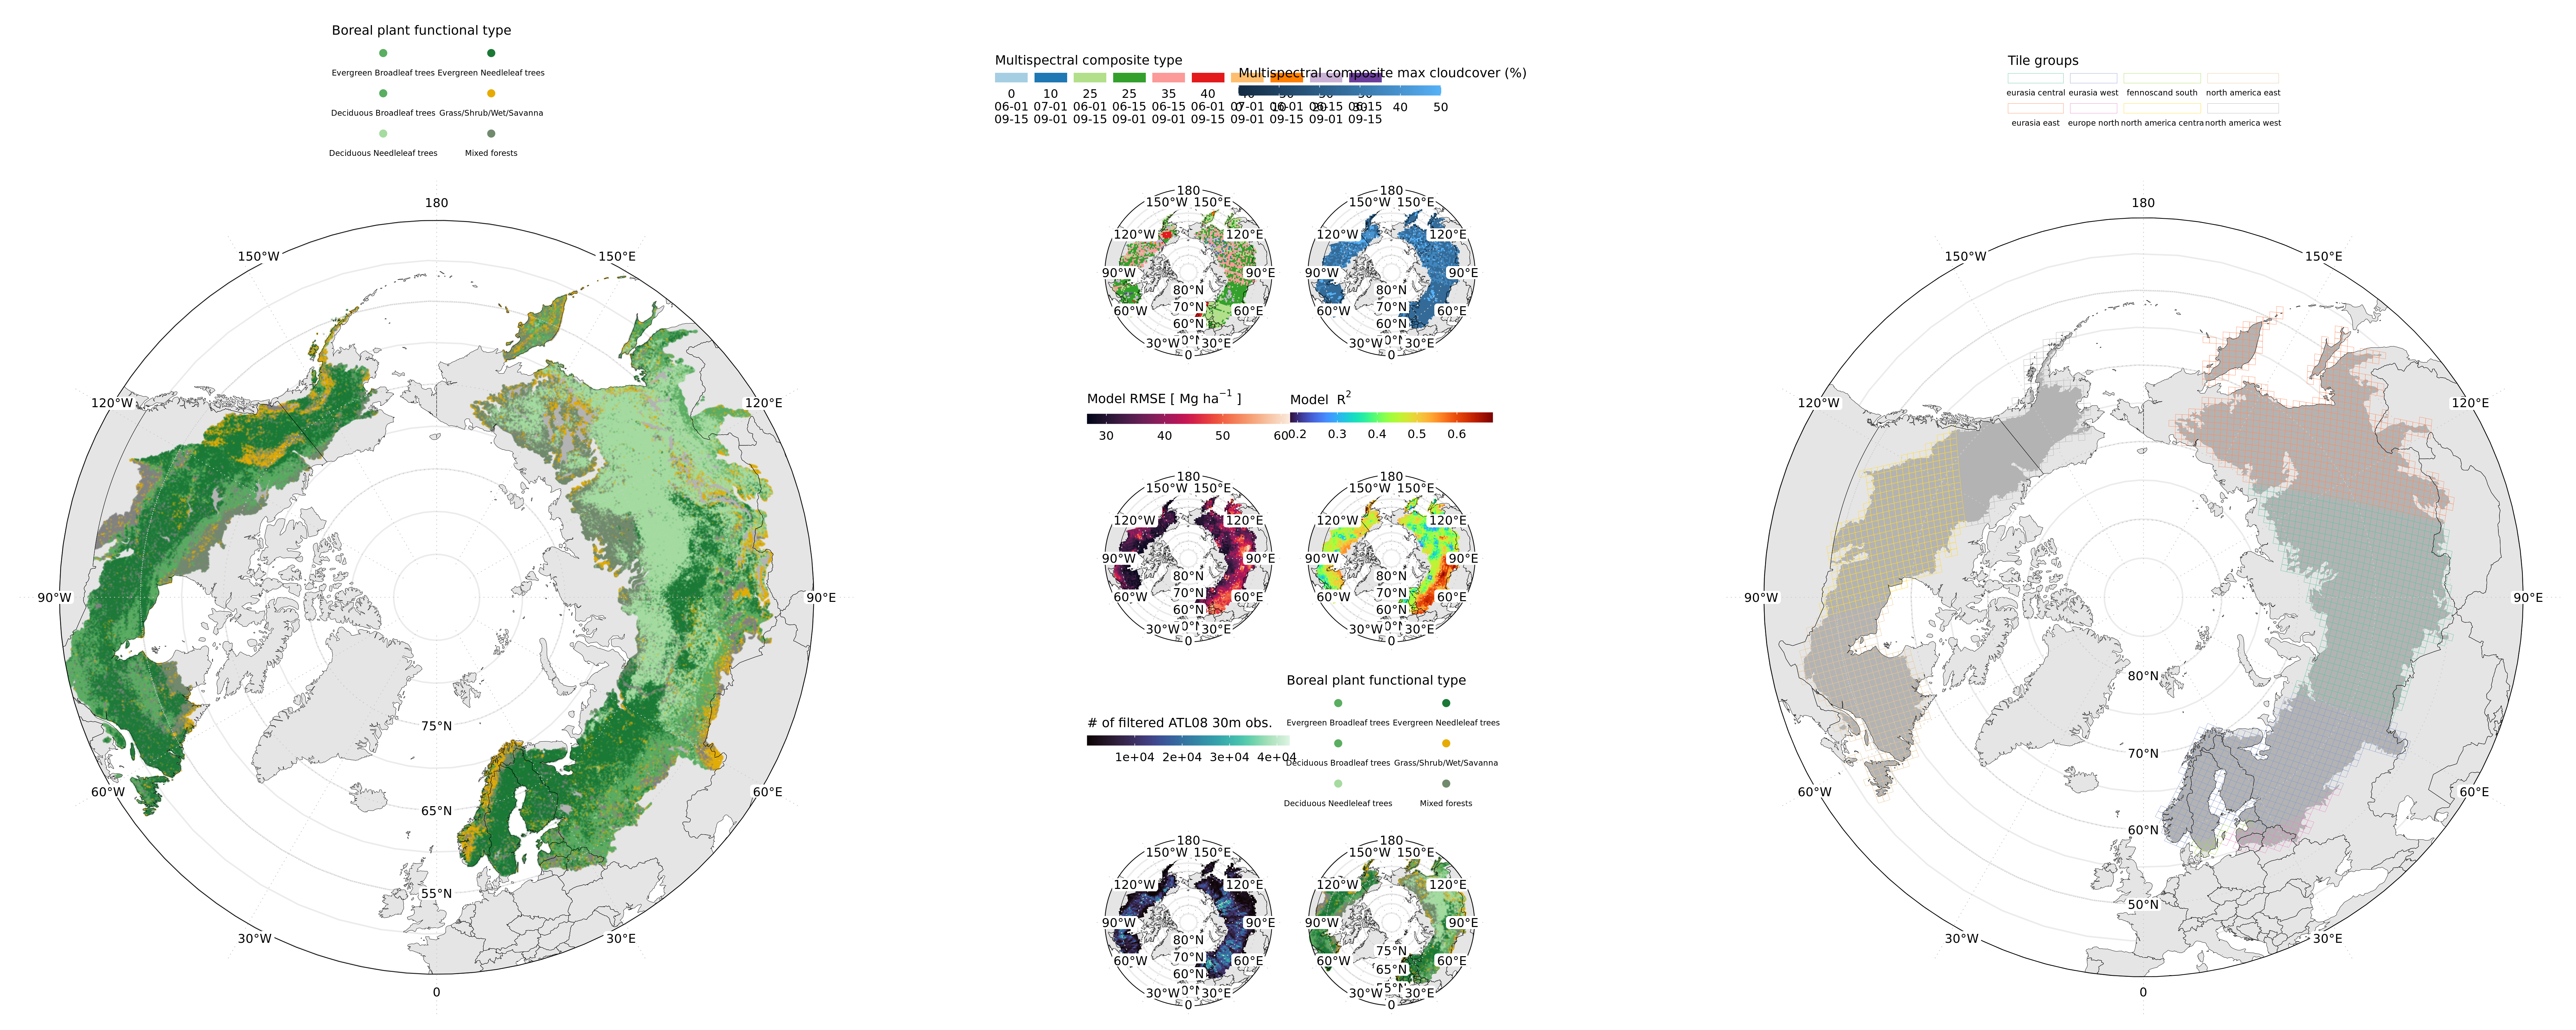

In [43]:
m_pft | ( (m_hls_runname | m_hls_maxcloud) / (m_rmse | m_r2) / (m_ATL08obs | m_pft) ) | m_groups + 
#plot_layout(ncol = 3) + 
plot_annotation(tag_levels = "a")